In [121]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.dpi'] = 100

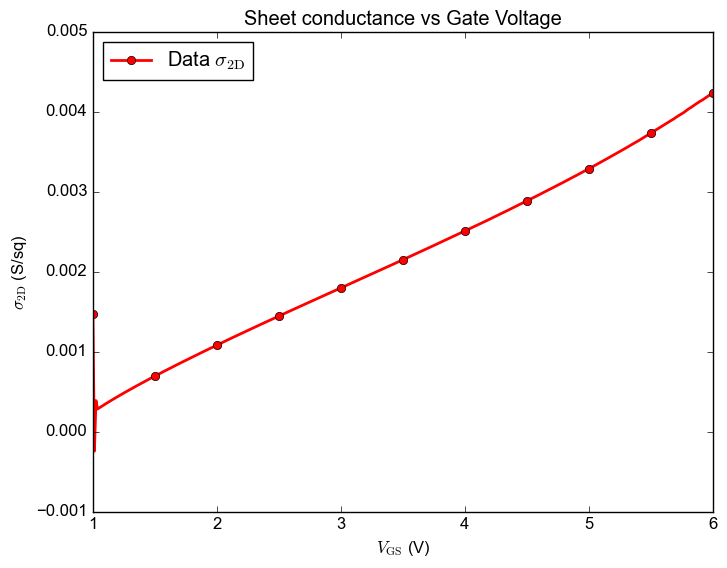

In [122]:
data = np.loadtxt("./Mobility/20262004004.dat")
V_GS = data[:, 0]
I_DS = data[:, 2]
V_DS = data[:, 3]
V_12 = data[:, 6]
sigma = data[:, 7]

plt.plot(V_GS, sigma, lw=2, label=r'Data $\sigma_\text{2D}$', color='red', marker='o', linestyle='-', markevery=40)
plt.xlabel(r"$V_\text{GS}$ (V)")
plt.ylabel(r"$\sigma_\text{2D}$ (S/sq)")
plt.legend(frameon=True, loc='upper left', numpoints=1)
plt.title("Sheet conductance vs Gate Voltage")
plt.show()


a = 0.0007553 ± 2.74e-06
b = -0.000461509 ± 1.04e-05
R^2 = 0.994782
V_T = (0.611027 ± 0.0228) V
mu = (755.3 ± 2.74) cm^2/Vs


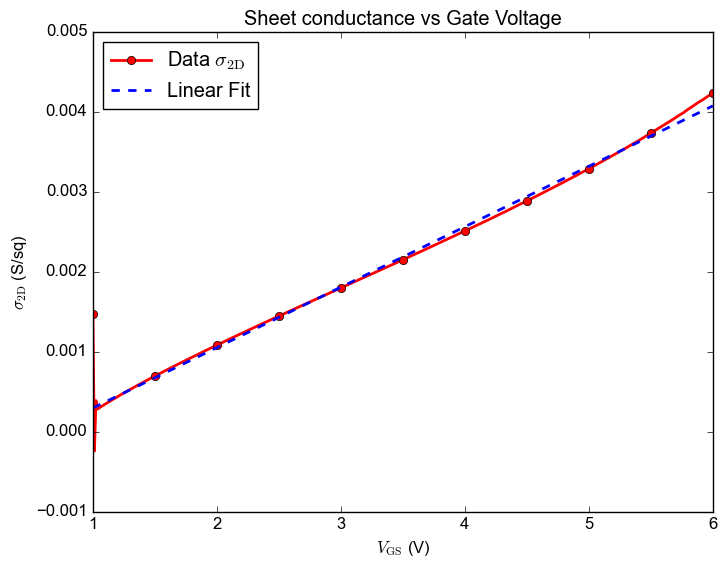

In [123]:
Ci = 1e-2 # F/m^2

def func(x, a, b):
    return a * x + b

popt, pcov = curve_fit(func, V_GS, sigma)
sigma_fit = func(V_GS, *popt)
a, b = popt

# Coefficient of determination
ss_res = np.sum((sigma - sigma_fit) ** 2)
ss_tot = np.sum((sigma - np.mean(sigma)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr
V_T_fit = -b/a
mu_fit = a/Ci*1e4

print(f"a = {a:.6g} ± {a_err:.3g}")
print(f"b = {b:.6g} ± {b_err:.3g}")
print(f"R^2 = {r2:.6f}")

print(f"V_T = ({-b/a:.6g} ± {np.sqrt((b_err/b)**2 + (a_err/a)**2):.3g}) V")
print(f"mu = ({a/Ci*1e4:.6g} ± {a_err/Ci*1e4:.3g}) cm^2/Vs")

plt.plot(V_GS, sigma, lw=2, label=r'Data $\sigma_\text{2D}$', color='red', marker='o', linestyle='-', markevery=40)
plt.plot(V_GS, sigma_fit, lw=2, label='Linear Fit', color='blue', linestyle='--')
plt.xlabel(r"$V_\text{GS}$ (V)")
plt.ylabel(r"$\sigma_\text{2D}$ (S/sq)")
plt.legend(frameon=True, loc='upper left', numpoints=1)
plt.title("Sheet conductance vs Gate Voltage")
plt.show()

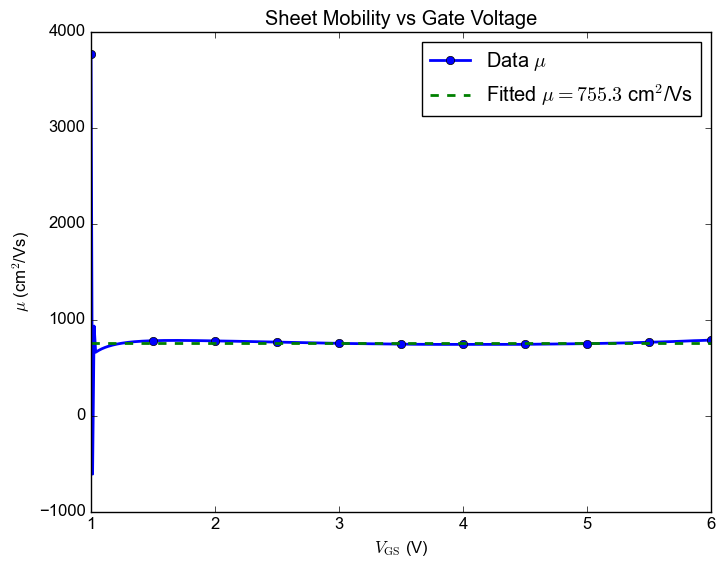

In [124]:

mu = sigma / Ci / (V_GS - V_T_fit) * 1e4 # cm^2/Vs
plt.plot(V_GS, mu, lw=2, label=r"Data $\mu$", color='blue', marker='o', linestyle='-', markevery=40)
plt.plot(V_GS, mu_fit * np.ones_like(V_GS), lw=2, label=rf"Fitted $\mu = {mu_fit:.6g}$ cm$^2$/Vs", color='green', linestyle='--')
plt.xlabel(r"$V_\text{GS}$ (V)")
plt.ylabel(r"$\mu$ (cm$^2$/Vs)")
plt.legend(frameon=True, loc='upper right', numpoints=1)
plt.title("Sheet Mobility vs Gate Voltage")
plt.show()

